# Notebook 08 : FastAPI backend

This notebook exposes CX Assist as a local REST API for the Streamlit frontend. It supports case discovery, Case 360 lookup, investigation start, human review/resume, and S3 audit history.

> This demo server binds only to `127.0.0.1`. Keep this notebook running while using the frontend.

## 1. Dependency check

Add these entries to `requirement.txt` if they are not already present:

```text
fastapi
uvicorn
httpx
```

Then run `pip install -r requirement.txt` from the activated virtual environment.

In [1]:
from __future__ import annotations

import hashlib
import json
import threading
import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Literal
from uuid import uuid4

try:
    import uvicorn
    from fastapi import FastAPI, HTTPException, Query
    from fastapi.middleware.cors import CORSMiddleware
    from fastapi.testclient import TestClient
    from pydantic import BaseModel, Field
except ImportError as exc:
    raise RuntimeError('Install fastapi, uvicorn, and httpx, then restart the kernel.') from exc

print('FastAPI dependencies are ready.')

FastAPI dependencies are ready.


## 2. Bootstrap the Notebook 05 workflow

AWS profile=CXASSIST, region=ap-south-1, bucket=s3://rahulcxassistdemo/cx-copilot/dev
Model provider=groq, temperature=0.0
Ready: provider=groq, model=openai/gpt-oss-120b
Structured rows: {'cases': 5, 'customers': 5, 'vehicles': 5, 'contracts': 5, 'invoices': 6, 'payments': 5, 'service_records': 5, 'case_interactions': 7}
Policy documents: 4
Available cases: ['CASE-3021', 'CASE-3022', 'CASE-3023', 'CASE-3024', 'CASE-3025']
Workflow compiled successfully.


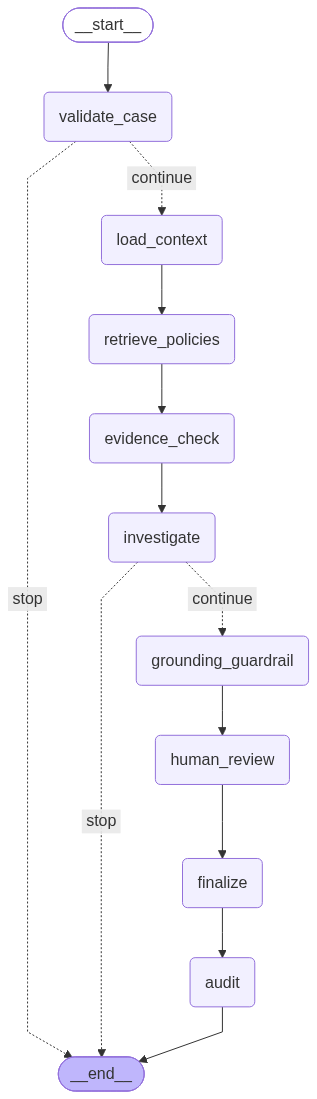

Loaded 8 code cells. Backend dependencies are ready.


In [2]:
NOTEBOOK_05 = Path('05_langgraph_workflow.ipynb')
if not NOTEBOOK_05.exists():
    raise FileNotFoundError('Place 05_langgraph_workflow.ipynb in the same folder as Notebook 08.')

source_notebook = json.loads(NOTEBOOK_05.read_text(encoding='utf-8'))
loaded_cells = 0
for cell in source_notebook['cells']:
    if cell['cell_type'] != 'code':
        continue
    source = ''.join(cell['source'])
    if 'SELECTED_CASE_ID =' in source:
        break
    exec(compile(source, f'{NOTEBOOK_05}:cell-{loaded_cells}', 'exec'), globals())
    loaded_cells += 1

required = ['workflow', 'datasets', 'get_case_context', 's3', 'S3_BUCKET', 'S3_PREFIX', 'Command']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f'Workflow bootstrap did not create: {missing}')
print(f'Loaded {loaded_cells} code cells. Backend dependencies are ready.')

## 3. API request and response contracts

In [3]:
class InvestigationRequest(BaseModel):
    case_id: str = Field(min_length=1, examples=['CASE-3022'])

class ReviewRequest(BaseModel):
    decision: Literal['approve', 'edit', 'reject', 'escalate']
    reviewer_id: str = Field(min_length=1)
    comments: str = ''
    edited_response: str | None = None

class InvestigationStarted(BaseModel):
    thread_id: str
    case_id: str
    status: str
    review_payload: dict[str, Any]

class ReviewCompleted(BaseModel):
    thread_id: str
    case_id: str
    status: str
    investigation: dict[str, Any]
    final_response: str | None
    audit_record: dict[str, Any]

def normalize_case_id(case_id: str) -> str:
    return case_id.strip().upper()

## 4. Runtime registry and S3 audit helper

The pending-run registry is process-local for the demo. LangGraph owns the actual checkpoint state; the registry prevents unknown or already-completed threads from being reviewed.

In [4]:
AUDIT_PREFIX = f'{S3_PREFIX}/audit-events'
pending_runs: dict[str, dict[str, Any]] = {}
completed_runs: dict[str, dict[str, Any]] = {}
registry_lock = threading.Lock()

def canonical_bytes(value: dict[str, Any]) -> bytes:
    return json.dumps(value, sort_keys=True, separators=(',', ':'), default=str).encode('utf-8')

def persist_api_audit(state: dict[str, Any], thread_id: str, duration_seconds: float) -> tuple[dict[str, Any], str]:
    investigation = state.get('investigation', {})
    decision = state.get('human_decision', {})
    recorded = datetime.now(timezone.utc)
    event = {
        'schema_version': '1.0',
        'event_id': state.get('audit_record', {}).get('event_id', str(uuid4())),
        'recorded_at_utc': recorded.isoformat(),
        'thread_id': thread_id,
        'case_id': state.get('case_id'),
        'issue_type': investigation.get('issue_type'),
        'provider': MODEL_PROVIDER,
        'model': MODEL_NAME,
        'final_status': state.get('final_status'),
        'decision': decision.get('decision'),
        'reviewer_id': decision.get('reviewer_id'),
        'confidence': investigation.get('confidence'),
        'evidence_reference_ids': sorted({item.get('reference_id') for item in investigation.get('evidence', []) if item.get('reference_id')}),
        'policy_document_ids': sorted({item.get('document_id') for item in investigation.get('policy_citations', []) if item.get('document_id')}),
        'warning_count': len(state.get('warnings', [])),
        'duration_seconds': round(duration_seconds, 3),
        'data_classification': 'internal-demo',
    }
    event['payload_sha256'] = hashlib.sha256(canonical_bytes(event)).hexdigest()
    key = f"{AUDIT_PREFIX}/{recorded:%Y/%m/%d}/{event['case_id']}/{thread_id}.json"
    s3.put_object(
        Bucket=S3_BUCKET, Key=key,
        Body=json.dumps(event, indent=2).encode('utf-8'),
        ContentType='application/json', ServerSideEncryption='AES256',
        Metadata={'case-id': event['case_id'], 'thread-id': thread_id, 'payload-sha256': event['payload_sha256']},
    )
    return event, key

## 5. Create the FastAPI application and endpoints

In [5]:
app = FastAPI(
    title='CX Assist API',
    description='Internal human-reviewed CX investigation service',
    version='0.1.0',
)
app.add_middleware(
    CORSMiddleware,
    allow_origins=['http://localhost:8501', 'http://127.0.0.1:8501'],
    allow_credentials=False, allow_methods=['GET', 'POST'], allow_headers=['Content-Type'],
)

@app.get('/health', tags=['system'])
def health() -> dict[str, Any]:
    return {'status': 'healthy', 'provider': MODEL_PROVIDER, 'model': MODEL_NAME, 'case_count': len(datasets['cases'])}

@app.get('/cases', tags=['cases'])
def list_cases() -> list[dict[str, Any]]:
    columns = [column for column in ('case_id', 'issue_type', 'priority', 'status', 'subject') if column in datasets['cases'].columns]
    return datasets['cases'][columns].fillna('').to_dict('records')

@app.get('/cases/{case_id}', tags=['cases'])
def case_details(case_id: str) -> dict[str, Any]:
    normalized = normalize_case_id(case_id)
    try:
        return get_case_context(normalized)
    except ValueError as exc:
        raise HTTPException(status_code=404, detail=str(exc)) from exc

@app.post('/investigations', response_model=InvestigationStarted, tags=['investigations'])
def start_investigation(request: InvestigationRequest) -> InvestigationStarted:
    case_id = normalize_case_id(request.case_id)
    valid_ids = set(datasets['cases']['case_id'].astype(str))
    if case_id not in valid_ids:
        raise HTTPException(status_code=404, detail=f'Unknown case_id: {case_id}')
    thread_id = f'api-{case_id}-{uuid4()}'
    config = {'configurable': {'thread_id': thread_id}}
    started = time.perf_counter()
    state = workflow.invoke({'case_id': case_id}, config=config)
    interrupts = state.get('__interrupt__', [])
    if not interrupts:
        raise HTTPException(status_code=500, detail={'message': 'Workflow did not reach human review', 'state': state})
    with registry_lock:
        pending_runs[thread_id] = {'case_id': case_id, 'started': started, 'created_at_utc': datetime.now(timezone.utc).isoformat()}
    return InvestigationStarted(thread_id=thread_id, case_id=case_id, status='awaiting_review', review_payload=interrupts[0].value)

@app.post('/investigations/{thread_id}/review', response_model=ReviewCompleted, tags=['investigations'])
def review_investigation(thread_id: str, request: ReviewRequest) -> ReviewCompleted:
    with registry_lock:
        run = pending_runs.get(thread_id)
    if not run:
        raise HTTPException(status_code=404, detail='Pending workflow thread not found or already reviewed.')
    if request.decision == 'edit' and not request.edited_response:
        raise HTTPException(status_code=422, detail='edited_response is required for an edit decision.')
    decision = request.model_dump()
    config = {'configurable': {'thread_id': thread_id}}
    state = workflow.invoke(Command(resume=decision), config=config)
    duration = time.perf_counter() - run['started']
    audit_event, audit_key = persist_api_audit(state, thread_id, duration)
    audit_event['s3_key'] = audit_key
    with registry_lock:
        pending_runs.pop(thread_id, None)
        completed_runs[thread_id] = {'case_id': run['case_id'], 'status': state.get('final_status'), 'audit_key': audit_key}
    return ReviewCompleted(
        thread_id=thread_id, case_id=run['case_id'], status=state.get('final_status', 'unknown'),
        investigation=state.get('investigation', {}), final_response=state.get('final_response'), audit_record=audit_event,
    )

@app.get('/runs/{thread_id}', tags=['investigations'])
def run_status(thread_id: str) -> dict[str, Any]:
    with registry_lock:
        if thread_id in pending_runs:
            return {'thread_id': thread_id, 'status': 'awaiting_review', **pending_runs[thread_id]}
        if thread_id in completed_runs:
            return {'thread_id': thread_id, **completed_runs[thread_id]}
    raise HTTPException(status_code=404, detail='Run not found.')

@app.get('/audit-events', tags=['audit'])
def audit_events(limit: int = Query(default=20, ge=1, le=100)) -> list[dict[str, Any]]:
    objects = []
    paginator = s3.get_paginator('list_objects_v2')
    for page in paginator.paginate(Bucket=S3_BUCKET, Prefix=f'{AUDIT_PREFIX}/'):
        objects.extend(item for item in page.get('Contents', []) if item['Key'].endswith('.json'))
    newest = sorted(objects, key=lambda item: item['LastModified'], reverse=True)[:limit]
    output = []
    for item in newest:
        body = s3.get_object(Bucket=S3_BUCKET, Key=item['Key'])['Body'].read()
        output.append(json.loads(body.decode('utf-8')))
    return output

print('API created with', len(app.routes), 'routes.')

API created with 11 routes.


## 6. Fast endpoint tests without an LLM call

In [6]:
client = TestClient(app)

health_response = client.get('/health')
cases_response = client.get('/cases')
known_case_response = client.get('/cases/CASE-3022')
unknown_case_response = client.get('/cases/CASE-NOT-FOUND')

endpoint_checks = {
    'health_200': health_response.status_code == 200,
    'cases_200': cases_response.status_code == 200 and len(cases_response.json()) > 0,
    'known_case_200': known_case_response.status_code == 200,
    'unknown_case_404': unknown_case_response.status_code == 404,
}
display(endpoint_checks)
if not all(endpoint_checks.values()):
    raise RuntimeError(f'Endpoint checks failed: {endpoint_checks}')
print('FAST API CHECKS: PASSED ✅')

{'health_200': True,
 'cases_200': True,
 'known_case_200': True,
 'unknown_case_404': True}

FAST API CHECKS: PASSED ✅


## 7. Test the investigation and human-review API flow

This cell makes one real LLM call. It starts the workflow but does not approve it.

In [7]:
api_start_response = client.post('/investigations', json={'case_id': 'CASE-3022'})
if api_start_response.status_code != 200:
    raise RuntimeError(api_start_response.json())
api_started = api_start_response.json()
API_THREAD_ID = api_started['thread_id']
print('Status:', api_started['status'])
print('Thread:', API_THREAD_ID)
display(JSON(api_started['review_payload']))

Status: awaiting_review
Thread: api-CASE-3022-8a0ccbfd-1a57-4d56-9353-74052e3dfa67


<IPython.core.display.JSON object>

## 8. Approve, edit, reject, or escalate through the API

Inspect the previous payload before executing this cell.

In [8]:
api_review_request = {
    'decision': 'approve',
    'reviewer_id': 'DEMO-REVIEWER',
    'comments': 'Reviewed through the FastAPI endpoint.',
    'edited_response': None,
}
api_review_response = client.post(f'/investigations/{API_THREAD_ID}/review', json=api_review_request)
if api_review_response.status_code != 200:
    raise RuntimeError(api_review_response.json())
api_completed = api_review_response.json()
print('Final status:', api_completed['status'])
print('Customer response:\n', api_completed['final_response'])
display(JSON(api_completed['audit_record']))

Final status: approved
Customer response:
 Hi Noah,

Thank you for bringing this to our attention. We have verified that two separate ACH transactions were posted for the same lease period. Our Billing Operations team is currently reviewing the duplicate charge and will determine the appropriate reversal. We will follow up with you as soon as the review is complete.

We appreciate your patience.

Best regards,
Customer Experience Team


<IPython.core.display.JSON object>

## 9. Start the local API server

Run this once. Keep the kernel alive. Swagger documentation will be available at `http://127.0.0.1:8000/docs`.

In [ ]:
API_HOST = '127.0.0.1'
API_PORT = 8000

if 'api_server' in globals() and getattr(api_server, 'started', False):
    print(f'API already running at http://{API_HOST}:{API_PORT}')
else:
    server_config = uvicorn.Config(app=app, host=API_HOST, port=API_PORT, log_level='info')
    api_server = uvicorn.Server(server_config)
    api_thread = threading.Thread(target=api_server.run, daemon=True, name='cx-assist-api')
    api_thread.start()
    for _ in range(50):
        if api_server.started:
            break
        time.sleep(0.1)
    if not api_server.started:
        raise RuntimeError('API server did not start. Check whether port 8000 is already in use.')
    print(f'API running: http://{API_HOST}:{API_PORT}')
    print(f'Swagger UI: http://{API_HOST}:{API_PORT}/docs')

INFO:     Started server process [5256]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


API running: http://127.0.0.1:8000
Swagger UI: http://127.0.0.1:8000/docs


INFO:     127.0.0.1:50384 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:50384 - "GET /openapi.json HTTP/1.1" 200 OK


## 10. Confirm the live server

In [ ]:
import urllib.request

with urllib.request.urlopen(f'http://{API_HOST}:{API_PORT}/health', timeout=10) as response:
    live_health = json.loads(response.read().decode('utf-8'))
display(JSON(live_health))
print('LIVE API: READY ✅')

INFO:     127.0.0.1:64738 - "GET /health HTTP/1.1" 200 OK


<IPython.core.display.JSON object>

LIVE API: READY ✅


INFO:     127.0.0.1:55112 - "GET /health HTTP/1.1" 200 OK
INFO:     127.0.0.1:55714 - "GET /health HTTP/1.1" 200 OK
INFO:     127.0.0.1:55715 - "GET /cases HTTP/1.1" 200 OK
INFO:     127.0.0.1:55716 - "GET /cases/CASE-3022 HTTP/1.1" 200 OK
INFO:     127.0.0.1:55717 - "GET /audit-events?limit=50 HTTP/1.1" 200 OK
INFO:     127.0.0.1:65359 - "GET /health HTTP/1.1" 200 OK
INFO:     127.0.0.1:65360 - "GET /cases/CASE-3023 HTTP/1.1" 200 OK
INFO:     127.0.0.1:65361 - "GET /audit-events?limit=50 HTTP/1.1" 200 OK
INFO:     127.0.0.1:65363 - "GET /cases HTTP/1.1" 200 OK
INFO:     127.0.0.1:65364 - "POST /investigations HTTP/1.1" 200 OK
INFO:     127.0.0.1:57666 - "GET /health HTTP/1.1" 200 OK
INFO:     127.0.0.1:57667 - "GET /cases/CASE-3023 HTTP/1.1" 200 OK
INFO:     127.0.0.1:57668 - "GET /audit-events?limit=50 HTTP/1.1" 200 OK
INFO:     127.0.0.1:55747 - "GET /health HTTP/1.1" 200 OK
INFO:     127.0.0.1:55748 - "GET /cases/CASE-3023 HTTP/1.1" 200 OK
INFO:     127.0.0.1:55749 - "GET /audit-ev

## 11. Stop the server when needed

In [ ]:
# Do not run this cell until you are finished with the frontend.
# api_server.should_exit = True
# api_thread.join(timeout=10)
# print('API server stopped.')

## API routes

| Method | Route | Purpose |
|---|---|---|
| GET | `/health` | Backend and provider status |
| GET | `/cases` | List selectable cases |
| GET | `/cases/{case_id}` | Retrieve Case 360 |
| POST | `/investigations` | Start and pause an investigation |
| POST | `/investigations/{thread_id}/review` | Resume with human decision |
| GET | `/runs/{thread_id}` | Check pending/completed status |
| GET | `/audit-events` | Retrieve recent durable audit events |

Notebook 09 will consume these endpoints from Streamlit.